Title: Data Exploration
Author: Kolbe Sussman


In [ ]:
import pandas as pd
import networkx as nx
from itertools import combinations
from collections import Counter
import ast



In [2]:
df = pd.read_csv("../data/processed/umich_works_cleaned.csv")
df.head()

,id,doi,title,authorships,topics,primary_topic,cited_by_count,publication_year,related_works,concepts,authorships_parsed,author_ids,author_names,institutions,raw_affiliations,topics_parsed,topic_ids,display_names,topic_scores
0,https://openalex.org/W4235678817,https://doi.org/10.1177/002224378101800104,Evaluating Structural Equation Models with Uno...,"[{'author_position': 'first', 'author': {'id':...","[{'id': 'https://openalex.org/T10467', 'displa...","{'id': 'https://openalex.org/T10467', 'display...",64467,1981,"['https://openalex.org/W2614563012', 'https://...","[{'id': 'https://openalex.org/C2780695315', 'w...","[{'author_position': 'first', 'author': {'id':...","['https://openalex.org/A5047556013', 'https://...","['Claes Fornell', 'David F. Larcker']",['University of Michigan–Ann Arbor'],"['The University of Michigan', 'Northwestern U...","[{'id': 'https://openalex.org/T10467', 'displa...","['https://openalex.org/T10467', 'https://opena...","['Psychometric Methodologies and Testing', 'Mu...","[0.9793999791145325, 0.9490000009536743, 0.941..."
1,https://openalex.org/W1791587663,https://doi.org/10.2307/249008,"Perceived Usefulness, Perceived Ease of Use, a...","[{'author_position': 'first', 'author': {'id':...","[{'id': 'https://openalex.org/T10068', 'displa...","{'id': 'https://openalex.org/T10068', 'display...",61935,1989,"['https://openalex.org/W4389670110', 'https://...","[{'id': 'https://openalex.org/C2776185967', 'w...","[{'author_position': 'first', 'author': {'id':...",['https://openalex.org/A5103061328'],['Fred D. Davis'],['University of Michigan–Ann Arbor'],['Computer and Information Systems'],"[{'id': 'https://openalex.org/T10068', 'displa...","['https://openalex.org/T10068', 'https://opena...","['Technology Adoption and User Behaviour', 'Kn...","[0.9998000264167786, 0.9921000003814697, 0.985..."
2,https://openalex.org/W1987258130,https://doi.org/10.2307/3151312,Evaluating Structural Equation Models with Uno...,"[{'author_position': 'first', 'author': {'id':...","[{'id': 'https://openalex.org/T10467', 'displa...","{'id': 'https://openalex.org/T10467', 'display...",60116,1981,"['https://openalex.org/W2614563012', 'https://...","[{'id': 'https://openalex.org/C2780695315', 'w...","[{'author_position': 'first', 'author': {'id':...","['https://openalex.org/A5047556013', 'https://...","['Claes Fornell', 'David F. Larcker']","['University of Michigan–Ann Arbor', 'Northwes...","['Northwestern University****', 'U. Michigan#T...","[{'id': 'https://openalex.org/T10467', 'displa...","['https://openalex.org/T10467', 'https://opena...","['Psychometric Methodologies and Testing', 'Ad...","[0.9904999732971191, 0.9409000277519226]"
3,https://openalex.org/W2097117768,https://doi.org/10.1109/cvpr.2015.7298594,Going deeper with convolutions,"[{'author_position': 'first', 'author': {'id':...","[{'id': 'https://openalex.org/T10036', 'displa...","{'id': 'https://openalex.org/T10036', 'display...",46263,2015,"['https://openalex.org/W2364252372', 'https://...","[{'id': 'https://openalex.org/C41008148', 'wik...","[{'author_position': 'first', 'author': {'id':...","['https://openalex.org/A5002183320', 'https://...","['Christian Szegedy', 'Wei Liu', 'Yangqing Jia...","['Magic Leap (United States)', 'Google (United...","['Google', 'IGoogle Inc', 'University of North...","[{'id': 'https://openalex.org/T10036', 'displa...","['https://openalex.org/T10036', 'https://opena...","['Advanced Neural Network Applications', 'Adva...","[0.9998999834060669, 0.9994999766349792, 0.999..."
4,https://openalex.org/W2117539524,https://doi.org/10.1007/s11263-015-0816-y,ImageNet Large Scale Visual Recognition Challenge,"[{'author_position': 'first', 'author': {'id':...","[{'id': 'https://openalex.org/T10627', 'displa...","{'id': 'https://openalex.org/T10627', 'display...",39595,2015,"['https://openalex.org/W2095705906', 'https://...","[{'id': 'https://openalex.org/C185798385', 'wi...","[{'author_position': 'first', 'author': {'id':...","['https://openalex.org/

In [3]:
df = df.groupby('title').first().reset_index()   # delete later - this was added to the preprocessing.py


In [4]:
def safe_parse(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []

df['author_names'] = df['author_names'].apply(safe_parse)
df['raw_affiliations'] = df['raw_affiliations'].apply(safe_parse)
df['author_ids'] = df['author_ids'].apply(safe_parse)


In [5]:
#sample graph
#full_df = df.copy()
#len(full_df)


In [6]:
#df = full_df.sample(10000)

In [7]:
# Extract author-level edges using pre-parsed column
MAX_AUTHORS = 20  # skip papers with too many authors

edge_weights = Counter()
author_info = {}

for row in df.itertuples(index=False):
    author_names = row.author_names
    raw_affiliations = row.raw_affiliations
    author_ids = row.author_ids

    if not author_names or len(author_names) < 2:
        continue

    if len(author_names) > MAX_AUTHORS:
        continue

    # remove duplicates just in case
    author_names = list(set(author_names))

    # store metadata
    for i, name in enumerate(author_names):
        if name not in author_info:
            author_info[name] = {
                'id': author_ids[i] if i < len(author_ids) else None,
                'affiliation': raw_affiliations[i] if i < len(raw_affiliations) else None
            }

    # generate edges
    for a, b in combinations(sorted(author_names), 2):
        edge_weights[(a, b)] += 1

In [8]:
total = len(edge_weights)

print(total)

1498395


In [ ]:
# Build NetworkX graph
G = nx.Graph()

for i, ((auth1, auth2), weight) in enumerate(edge_weights.items(), start=1):
    G.add_edge(auth1, auth2, weight=weight)
    
    if i % 10000 == 0:
        print(f"Processed {i}/{total} edges ({i/total:.1%})")



Processed 1000/1498395 edges (0.1%)
Processed 2000/1498395 edges (0.1%)
Processed 3000/1498395 edges (0.2%)
Processed 4000/1498395 edges (0.3%)
Processed 5000/1498395 edges (0.3%)
Processed 6000/1498395 edges (0.4%)
Processed 7000/1498395 edges (0.5%)
Processed 8000/1498395 edges (0.5%)
Processed 9000/1498395 edges (0.6%)
Processed 10000/1498395 edges (0.7%)
Processed 11000/1498395 edges (0.7%)
Processed 12000/1498395 edges (0.8%)
Processed 13000/1498395 edges (0.9%)
Processed 14000/1498395 edges (0.9%)
Processed 15000/1498395 edges (1.0%)
Processed 16000/1498395 edges (1.1%)
Processed 17000/1498395 edges (1.1%)
Processed 18000/1498395 edges (1.2%)
Processed 19000/1498395 edges (1.3%)
Processed 20000/1498395 edges (1.3%)
Processed 21000/1498395 edges (1.4%)
Processed 22000/1498395 edges (1.5%)
Processed 23000/1498395 edges (1.5%)
Processed 24000/1498395 edges (1.6%)
Processed 25000/1498395 edges (1.7%)
Processed 26000/1498395 edges (1.7%)
Processed 27000/1498395 edges (1.8%)
Processed 

KeyboardInterrupt: 

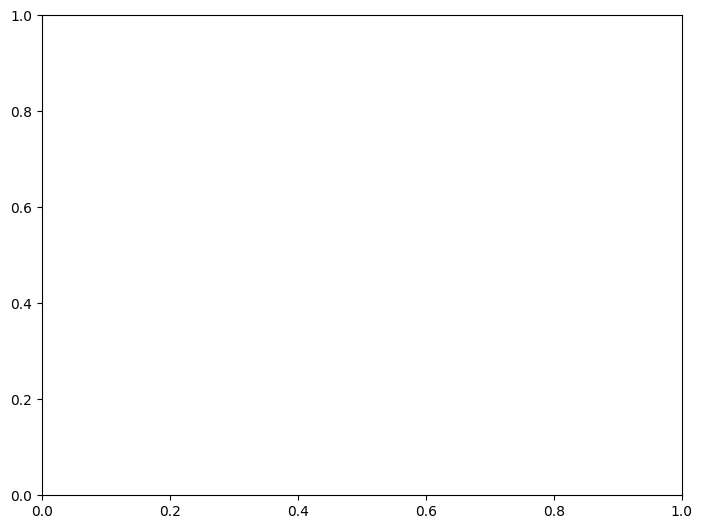

In [ ]:
# show graph
#nx.draw(G)

In [14]:
# Compute metrics
degree_centrality = nx.degree_centrality(G)
print("done")
#betweenness_centrality = nx.betweenness_centrality(G, weight='weight')
eigenvector_centrality = nx.eigenvector_centrality(G, weight='weight')
print("done")


done
done


In [15]:

# Save network metrics
metrics_df = pd.DataFrame({
    'author': list(G.nodes),
    'degree_centrality': [degree_centrality[a] for a in G.nodes],
    #'betweenness_centrality': [betweenness_centrality[a] for a in G.nodes],
    'eigenvector_centrality': [eigenvector_centrality[a] for a in G.nodes],
    'id': [author_info[a]['id'] for a in G.nodes],
    'affiliation': [author_info[a]['affiliation'] for a in G.nodes]
})

#metrics_df.to_csv("../data/processed/author_network_metrics.csv", index=False)

In [16]:
# Save full edge list
edges_df = pd.DataFrame([
    {'author_1': a1, 'author_2': a2, 'weight': w}
    for (a1, a2), w in edge_weights.items()
])
#edges_df.to_csv("../data/processed/author_network_edges.csv", index=False)

#print("Author network created and metrics saved!")